In [1]:
import sys
!{sys.executable} -m pip install pandas


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: C:\Users\rajan\mynewenv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: C:\Users\rajan\mynewenv\Scripts\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
from datetime import datetime, timedelta

d1 = pd.read_csv('bigBasket.csv')
d1

,Member,Order,SKU,Created On,Description
0,M09736,6468572,34993740,41904.94792,Other Sauces
1,M09736,6468572,15669800,41904.94792,Cashews
2,M09736,6468572,34989501,41904.94792,Other Dals
3,M09736,6468572,7572303,41904.94792,Namkeen
4,M09736,6468572,15669856,41904.94792,Sugar
...,...,...,...,...,...
62136,M64379,8381435,15670260,41594.02986,Organic F&V
62137,M64379,8381435,15668597,41594.02986,Exotic Vegetables
62138,M64379,8381435,7570555,41594.02986,Shoe Polish
62139,M64379,8381435,7587490,41594.02986,Organic Dals & Pulses


In [4]:
d1['Member'].unique()

<StringArray>
['M09736', 'M39021', 'M47229', 'M76390', 'M77779', 'M78365', 'M78720',
 'M82651', 'M84827', 'M86304',
 ...
 'M57354', 'M58761', 'M58939', 'M59012', 'M59232', 'M62656', 'M62833',
 'M63404', 'M64055', 'M64379']
Length: 106, dtype: str

In [5]:
print(d1["Created On"].head())
print(d1["Created On"].dtype)

0    41904.94792
1    41904.94792
2    41904.94792
3    41904.94792
4    41904.94792
Name: Created On, dtype: str
str


In [6]:
# Keep the original Created On column unchanged
created_on = d1["Created On"].astype(str).str.strip()

# Identify values that are Excel serial numbers
numeric_dates = pd.to_numeric(created_on, errors="coerce")

# Create a new clean datetime column
d1["Created On_clean"] = pd.NaT

# Convert Excel serial dates
excel_mask = numeric_dates.notna()

d1.loc[excel_mask, "Created On_clean"] = numeric_dates[excel_mask].map(
    lambda x: datetime(1899, 12, 30) + timedelta(days=float(x))
)

# Convert dates that are already written as text
text_mask = numeric_dates.isna()

d1.loc[text_mask, "Created On_clean"] = pd.to_datetime(
    created_on[text_mask],
    format="%d/%m/%y %H:%M",
    errors="coerce"
)

# Round to the nearest second
d1["Created On_clean"] = d1["Created On_clean"].dt.round("s")
d1[["Created On", "Created On_clean"]].head(10)

,Created On,Created On_clean
0,41904.94792,2014-09-22 22:45:00
1,41904.94792,2014-09-22 22:45:00
2,41904.94792,2014-09-22 22:45:00
3,41904.94792,2014-09-22 22:45:00
4,41904.94792,2014-09-22 22:45:00
5,41904.94792,2014-09-22 22:45:00
6,41904.94792,2014-09-22 22:45:00
7,41904.94792,2014-09-22 22:45:00
8,41904.94792,2014-09-22 22:45:00
9,41904.94792,2014-09-22 22:45:00


In [7]:
d1["Year"] = d1["Created On_clean"].dt.year
d1["Month"] = d1["Created On_clean"].dt.month
d1["Day_of_Week"] = d1["Created On_clean"].dt.dayofweek
d1["Hour"] = d1["Created On_clean"].dt.hour

d1["Day_Name"] = d1["Created On_clean"].dt.day_name()

d1[
    ["Created On_clean", "Year", "Month", 
     "Day_of_Week", "Hour", "Day_Name"]
].head()

,Created On_clean,Year,Month,Day_of_Week,Hour,Day_Name
0,2014-09-22 22:45:00,2014,9,0,22,Monday
1,2014-09-22 22:45:00,2014,9,0,22,Monday
2,2014-09-22 22:45:00,2014,9,0,22,Monday
3,2014-09-22 22:45:00,2014,9,0,22,Monday
4,2014-09-22 22:45:00,2014,9,0,22,Monday


In [8]:
# Check the data types
print(d1.dtypes)

# Check the number of unique values
print("\nUnique values:")
print(d1.nunique())

# Display the first 10 rows
d1.head(10)

Member                         str
Order                        int64
SKU                          int64
Created On                     str
Description                    str
Created On_clean    datetime64[ns]
Year                         int32
Month                        int32
Day_of_Week                  int32
Hour                         int32
Day_Name                       str
dtype: object

Unique values:
Member               106
Order               8387
SKU                 1732
Created On          8352
Description          216
Created On_clean    8352
Year                   4
Month                 12
Day_of_Week            7
Hour                  24
Day_Name               7
dtype: int64


,Member,Order,SKU,Created On,Description,Created On_clean,Year,Month,Day_of_Week,Hour,Day_Name
0,M09736,6468572,34993740,41904.94792,Other Sauces,2014-09-22 22:45:00,2014,9,0,22,Monday
1,M09736,6468572,15669800,41904.94792,Cashews,2014-09-22 22:45:00,2014,9,0,22,Monday
2,M09736,6468572,34989501,41904.94792,Other Dals,2014-09-22 22:45:00,2014,9,0,22,Monday
3,M09736,6468572,7572303,41904.94792,Namkeen,2014-09-22 22:45:00,2014,9,0,22,Monday
4,M09736,6468572,15669856,41904.94792,Sugar,2014-09-22 22:45:00,2014,9,0,22,Monday
5,M09736,6468572,15668478,41904.94792,Banana,2014-09-22 22:45:00,2014,9,0,22,Monday
6,M09736,6468572,21409124,41904.94792,Sugar Cubes,2014-09-22 22:45:00,2014,9,0,22,Monday
7,M09736,6468572,34938526,41904.94792,Other Sweets,2014-09-22 22:45:00,2014,9,0,22,Monday
8,M09736,6468572,15669778,41904.94792,Other Dals,2014-09-22 22:45:00,2014,9,0,22,Monday
9,M09736,6468572,34989440,41904.94792,Other Rice Products,2014-09-22 22:45:00,2014,9,0,22,Monday


In [9]:
print("Unique Members:", d1["Member"].nunique())
print("Unique Orders:", d1["Order"].nunique())
print("Unique SKUs:", d1["SKU"].nunique())
print("Unique Descriptions:", d1["Description"].nunique())

Unique Members: 106
Unique Orders: 8387
Unique SKUs: 1732
Unique Descriptions: 216


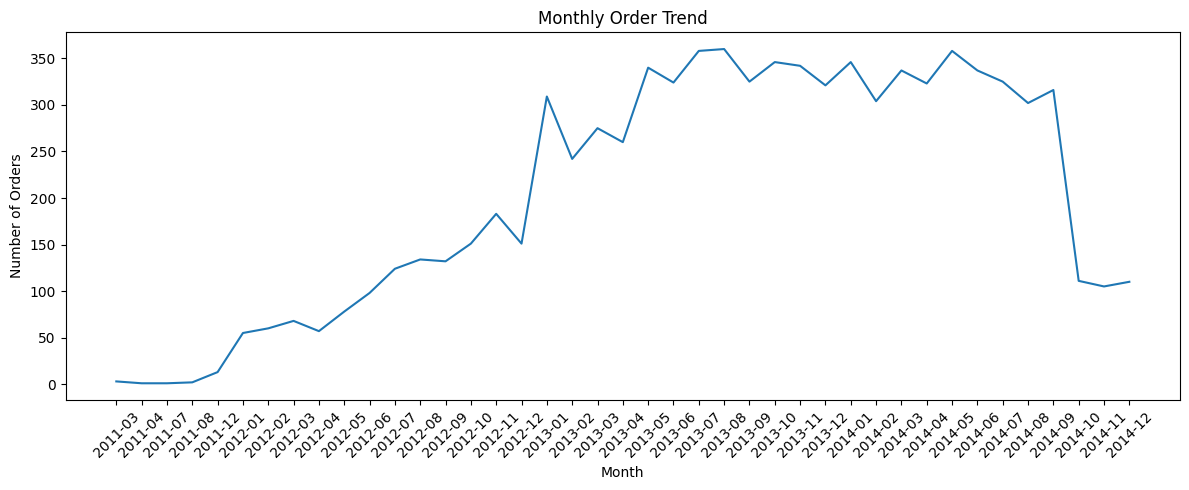

In [22]:
monthly_orders = (
    order_data.groupby(
        order_data["order_date"].dt.to_period("M")
    )["Order"]
    .nunique()
)

monthly_orders.index = monthly_orders.index.astype(str)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_orders.index,
    monthly_orders.values
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

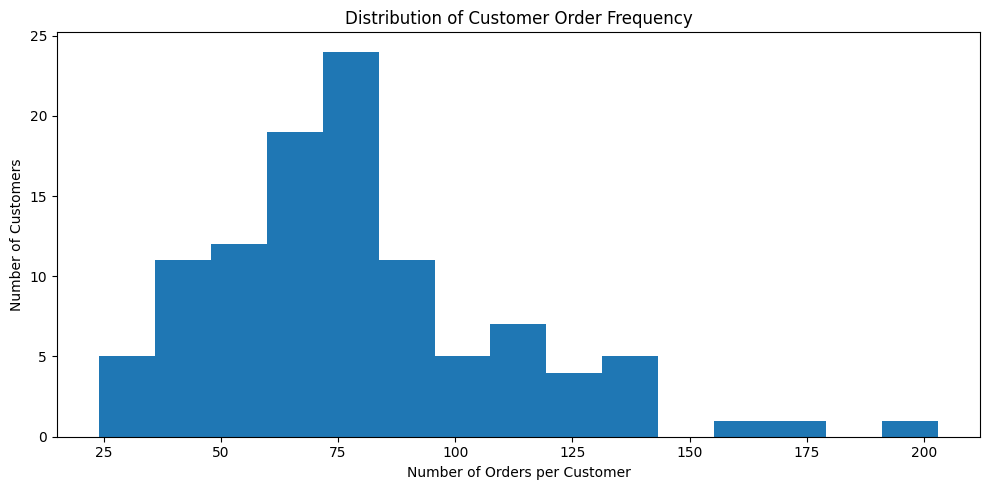

In [23]:
customer_orders = (
    order_data.groupby("Member")["Order"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.hist(
    customer_orders,
    bins=15
)

plt.title("Distribution of Customer Order Frequency")
plt.xlabel("Number of Orders per Customer")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

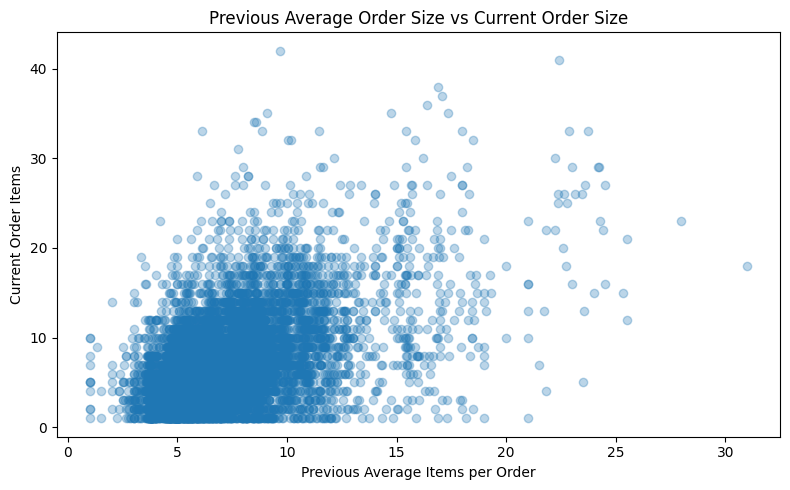

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(
    model_data["previous_avg_items"],
    model_data["total_items"],
    alpha=0.3
)

plt.title("Previous Average Order Size vs Current Order Size")
plt.xlabel("Previous Average Items per Order")
plt.ylabel("Current Order Items")

plt.tight_layout()
plt.show()

In [11]:
d1 = d1.sort_values(
    ["Member", "Created On_clean", "Order"]
).reset_index(drop=True)

In [12]:
order_data = d1.groupby("Order").agg(
    Member=("Member", "first"),
    order_date=("Created On_clean", "first"),
    total_items=("SKU", "count"),
    unique_products=("SKU", "nunique"),
    unique_descriptions=("Description", "nunique")
).reset_index()

order_data = order_data.sort_values(
    ["Member", "order_date", "Order"]
).reset_index(drop=True)

In [13]:
median_items = order_data["total_items"].median()

order_data["high_volume_order"] = (
    order_data["total_items"] > median_items
).astype(int)

print("Median order size:", median_items)
print(order_data["high_volume_order"].value_counts())

Median order size: 7.0
high_volume_order
0    4931
1    3456
Name: count, dtype: int64


In [14]:
order_data["previous_orders"] = (
    order_data.groupby("Member").cumcount()
)

order_data["previous_total_items"] = (
    order_data.groupby("Member")["total_items"]
    .shift(1)
)

order_data["previous_avg_items"] = (
    order_data.groupby("Member")["total_items"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

order_data["previous_order_date"] = (
    order_data.groupby("Member")["order_date"].shift(1)
)

order_data["days_since_previous_order"] = (
    order_data["order_date"] -
    order_data["previous_order_date"]
).dt.days

In [15]:
order_data["Year"] = order_data["order_date"].dt.year
order_data["Month"] = order_data["order_date"].dt.month
order_data["Day_of_Week"] = order_data["order_date"].dt.dayofweek
order_data["Hour"] = order_data["order_date"].dt.hour

In [16]:
model_data = order_data[
    order_data["previous_orders"] > 0
].copy()

print("Original orders:", len(order_data))
print("Orders available for modelling:", len(model_data))

Original orders: 8387
Orders available for modelling: 8281


In [17]:
features = [
    "previous_orders",
    "previous_avg_items",
    "days_since_previous_order",
    "Year",
    "Month",
    "Day_of_Week",
    "Hour"
]

X = model_data[features]
y = model_data["high_volume_order"]

In [18]:
print("Shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())

print("\nMissing values:")
print(X.isnull().sum())

Shape: (8281, 7)

Target distribution:
high_volume_order
0    4873
1    3408
Name: count, dtype: int64

Missing values:
previous_orders              0
previous_avg_items           0
days_since_previous_order    0
Year                         0
Month                        0
Day_of_Week                  0
Hour                         0
dtype: int64


In [19]:
from sklearn.model_selection import train_test_split

X = model_data[features]
y = model_data["high_volume_order"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (6624, 7)
Testing set: (1657, 7)


In [20]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

y_pred = dt_model.predict(X_test)

print(y_pred[:20])

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Decision Tree model trained successfully.
[1 0 1 1 1 0 0 0 0 1 0 0 1 1 0 0 1 0 0 1]
Accuracy : 0.5957
Precision: 0.5088
Recall   : 0.5059
F1-score : 0.5074
Confusion Matrix:
[[642 333]
 [337 345]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.66      0.66       975
           1       0.51      0.51      0.51       682

    accuracy                           0.60      1657
   macro avg       0.58      0.58      0.58      1657
weighted avg       0.60      0.60      0.60      1657



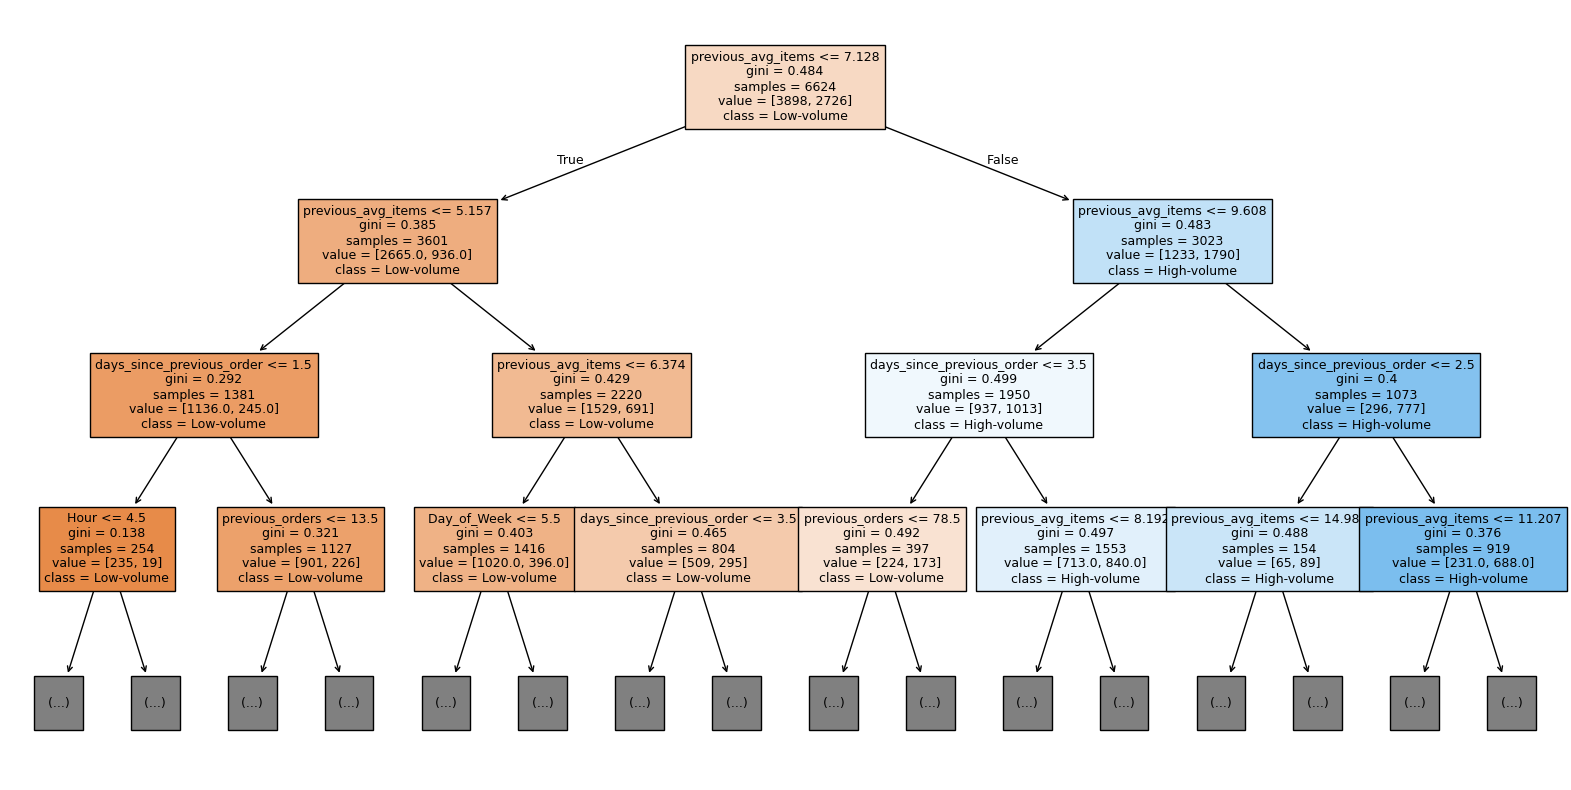

In [21]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=["Low-volume", "High-volume"],
    filled=True,
    max_depth=3,
    fontsize=9
)

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

baseline_accuracy = y_test.value_counts(normalize=True).max()

print("Baseline accuracy:", round(baseline_accuracy, 4))
print("Decision Tree accuracy:", round(accuracy, 4))
print(
    "Improvement:",
    round(accuracy - baseline_accuracy, 4)
)